# TP N°03 — NLP: Improving the TP02 Model
**Module:** Natural Language Processing | **Option:** IASD | **2ème année Second Cycle**

**Objectif :** Analyze the weaknesses of the TP02 pipeline and apply targeted improvements across preprocessing, vectorization, and model architecture to achieve better performance metrics while keeping the model efficient.

---
### Strategy Map
| Axis | TP02 (baseline) | TP03 (improved) |
|------|----------------|------------------|
| Preprocessing | basic tokenization / stopwords | bigrams + char n-grams |
| Vectorization | Count, TF-IDF, Word2Vec avg | TF-IDF tuned + SVD/LSA |
| Classifier | MLPClassifier (default) | LR, LinearSVC, tuned MLP, Voting Ensemble |
| Metric target | ~accuracy | accuracy + F1 + training/test time |

## 0. Installation & Imports

In [ ]:
# Install required packages if needed
!pip install scikit-learn pandas numpy gensim fasttext-wheel matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# Word embeddings
from gensim.models import Word2Vec, FastText

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ All imports successful')

✅ All imports successful


## 1. Load the Pre-processed Dataset (from TP01/TP02)

In [ ]:
# ─── Load your TP01 preprocessed CSV ─────────────────────────────────────────
# Replace with your actual file path
df = pd.read_csv('/content/spooky.csv')   # or 'spooky_preprocessed.csv' if you saved TP01 output

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(20)

Shape: (25846, 3)
Columns: ['id', 'text', 'author']


,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL
5,id22965,"A youth passed in solitude, my best years spen...",MWS
6,id09674,"The astronomer, perhaps, at this point, took r...",EAP
7,id13515,The surcingle hung in ribands from my body.,EAP
8,id19322,I knew that you could not say to yourself 'ste...,EAP
9,id00912,I confess that neither the structure of langua...,MWS


In [ ]:
import re
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# Ensure required NLTK data is downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added this line to fix the LookupError

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

def preprocess_for_authors(text: str, remove_stopwords: bool = False) -> str:
    """
    Tailored for Author Identification.
    Keeps stop words by default, as they are strong indicators of author style.
    """
    # 1. Lowercase
    text = str(text).lower()

    # 2. Keep letters and spaces (We strip punctuation here for TF-IDF/CountVectorizer,
    # but consider extracting punctuation counts as separate features first!)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tokenize
    tokens = word_tokenize(text)

    # 5. POS Tagging & Lemmatization
    pos_tags = pos_tag(tokens)

    clean_tokens = []
    # Notice we removed the stop_words filter here to preserve author style
    for word, tag in pos_tags:
        if len(word) > 1: # Keep smaller words like 'he', 'it', 'we'
            wordnet_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
            clean_tokens.append(lemma)

    return " ".join(clean_tokens)

# Apply the function
# Re-run your apply function
df['clean_text'] = df['text'].apply(preprocess_for_authors)
print('✅ Author-Optimized Preprocessing done')
display(df[['text', 'clean_text', 'author']].head(3))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


✅ Author-Optimized Preprocessing done


,text,clean_text,author
0,"This process, however, afforded me no means of...",this process however afford me no mean of asce...,EAP
1,It never once occurred to me that the fumbling...,it never once occur to me that the fumbling mi...,HPL
2,"In his left hand was a gold snuff box, from wh...",in his left hand be gold snuff box from which ...,EAP


## 2. Label Encoding

Classes: ['EAP' 'HPL' 'MWS']
Label distribution:
label
0    10395
1     7485
2     7966
Name: count, dtype: int64


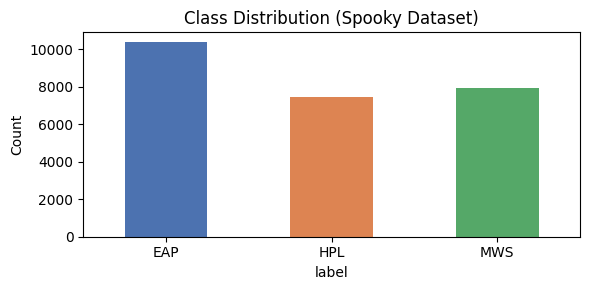

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df[LABEL_COL])

print('Classes:', le.classes_)
print('Label distribution:')
print(df['label'].value_counts().sort_index())

# Visualise class imbalance
fig, ax = plt.subplots(figsize=(6, 3))
df['label'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_xticklabels(le.classes_, rotation=0)
ax.set_title('Class Distribution (Spooky Dataset)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Train / Test Split — Stratified (same as TP02)

In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y          # preserves class proportions in both splits
)

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')
print('Train class distribution:'); print(pd.Series(y_train).value_counts().sort_index())

Train: 18092 samples | Test: 7754 samples
Train class distribution:
label
0    7276
1    5240
2    5576
Name: count, dtype: int64


---
## 4. Utility Functions

In [ ]:
results = {}   # global dict: model_name → metrics
def evaluate(name, clf, X_tr, X_te, y_tr, y_te):
    # Entraînement
    t0 = time.perf_counter()
    clf.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    # Test phase
    t1 = time.perf_counter()
    y_pred = clf.predict(X_te)
    test_time = time.perf_counter() - t1

    # NEW: Train phase prediction (to check for overfitting)
    y_pred_train = clf.predict(X_tr)
    acc_train = accuracy_score(y_tr, y_pred_train)

    acc_test = accuracy_score(y_te, y_pred)

    print(f'\n=== {name} ===')
    print(f'Train time : {train_time:.2f}s  |  Test time: {test_time:.4f}s')
    print(f'Accuracy TRAIN : {acc_train:.4f}') # <--- NEW
    print(f'Accuracy TEST  : {acc_test:.4f}')  # <--- NEW
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    results[name] = {
        'accuracy_train': round(acc_train, 4),
        'accuracy_test' : round(acc_test, 4),
        'train_time'    : round(train_time, 2),
        'test_time'     : round(test_time, 4),
        'report'        : classification_report(y_te, y_pred, target_names=le.classes_, output_dict=True)
    }

---
# PART A — TP02 BASELINES (Reproduced)
These are the TP02 reference scores. Every improvement in TP03 will be compared against them.

### Concept: Why TF-IDF is Better than Raw Counts
> **TF-IDF (Term Frequency – Inverse Document Frequency)** balances two forces:  
> - **TF**: reward words that appear often *in this document* → captures local relevance  
> - **IDF**: penalise words that appear in *most documents* ("the", "is") → filters noise  
> Raw count (Bag-of-Words) only measures TF, so common words dominate. TF-IDF is more discriminative.

In [ ]:
# ── A1. Bag-of-Words (Count) baseline ─────────────────────────────────────────
cv = CountVectorizer(max_features=10000)
X_tr_bow = cv.fit_transform(X_train)
X_te_bow = cv.transform(X_test)

mlp_bow = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=0)
evaluate('BASELINE — MLP + BoW', mlp_bow, X_tr_bow, X_te_bow, y_train, y_test)


=== BASELINE — MLP + BoW ===
Train time : 136.03s  |  Test time: 0.0229s
Accuracy TRAIN : 0.9999
Accuracy TEST  : 0.8473
              precision    recall  f1-score   support

         EAP       0.86      0.85      0.85      3119
         HPL       0.86      0.83      0.84      2245
         MWS       0.83      0.87      0.85      2390

    accuracy                           0.85      7754
   macro avg       0.85      0.85      0.85      7754
weighted avg       0.85      0.85      0.85      7754



In [ ]:
# ── A2. TF-IDF baseline ────────────────────────────────────────────────────────
tfidf_base = TfidfVectorizer(max_features=10000)
X_tr_tfidf = tfidf_base.fit_transform(X_train)
X_te_tfidf  = tfidf_base.transform(X_test)

mlp_tfidf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=0)
evaluate('BASELINE — MLP + TF-IDF', mlp_tfidf, X_tr_tfidf, X_te_tfidf, y_train, y_test)


=== BASELINE — MLP + TF-IDF ===
Train time : 113.14s  |  Test time: 0.0458s
Accuracy TRAIN : 0.9999
Accuracy TEST  : 0.8513
              precision    recall  f1-score   support

         EAP       0.85      0.86      0.85      3119
         HPL       0.87      0.83      0.85      2245
         MWS       0.83      0.87      0.85      2390

    accuracy                           0.85      7754
   macro avg       0.85      0.85      0.85      7754
weighted avg       0.85      0.85      0.85      7754



In [ ]:
# ── A3. Word2Vec Average Embedding baseline ────────────────────────────────────
EMBED_DIM = 100

train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM, window=5, min_count=2,
    sg=0,          # CBOW
    workers=4, epochs=10
)

X_tr_w2v = avg_embedding(train_tokens, w2v_model, EMBED_DIM)
X_te_w2v = avg_embedding(test_tokens,  w2v_model, EMBED_DIM)

mlp_w2v = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=0)
evaluate('BASELINE — MLP + Word2Vec CBOW', mlp_w2v, X_tr_w2v, X_te_w2v, y_train, y_test)


=== BASELINE — MLP + Word2Vec CBOW ===
Train time : 29.99s  |  Test time: 0.0134s
Accuracy TRAIN : 0.7889
Accuracy TEST  : 0.7022
              precision    recall  f1-score   support

         EAP       0.72      0.71      0.71      3119
         HPL       0.67      0.67      0.67      2245
         MWS       0.71      0.72      0.72      2390

    accuracy                           0.70      7754
   macro avg       0.70      0.70      0.70      7754
weighted avg       0.70      0.70      0.70      7754



---
# PART C — IMPROVEMENT 2: Better Vectorization (Bigrams + Character N-grams)

### Concept: N-grams and Character-level Features

**Word unigrams** treat each word independently and **lose word order**.  
"dark night" vs "night dark" → same representation. That's a big information loss for stylistic text.

**Bigrams** (consecutive word pairs) capture local context:
- "blood thirsty", "dark night", "old man" become single features
- Author style is often encoded in *phrase patterns*, not just individual words

**Character N-grams** (e.g. `char_wb`, n=3-6) capture:
- morphological patterns (suffixes, prefixes, roots)
- spelling quirks unique to an author's style
- partial word matches (useful for literary / Gothic text like Spooky)
- they are also *robust to typos* and rare words

**Feature combination** — stacking word and character TF-IDF gives the model two complementary views simultaneously.

In [ ]:
# ── C1. TF-IDF with Bigrams ────────────────────────────────────────────────────
tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=50000,
    sublinear_tf=True     # use log(TF) → compresses high-freq terms
)
X_tr_bi = tfidf_bigram.fit_transform(X_train)
X_te_bi = tfidf_bigram.transform(X_test)

lr_bi = LogisticRegression(C=5.0, solver='saga', max_iter=1000, random_state=0)
evaluate('IMP2a — LR + TF-IDF Bigrams', lr_bi, X_tr_bi, X_te_bi, y_train, y_test)


=== IMP2a — LR + TF-IDF Bigrams ===
Train time : 1.30s  |  Test time: 0.0024s
Accuracy TRAIN : 0.9978
Accuracy TEST  : 0.8879
              precision    recall  f1-score   support

         EAP       0.88      0.90      0.89      3119
         HPL       0.90      0.86      0.88      2245
         MWS       0.88      0.89      0.89      2390

    accuracy                           0.89      7754
   macro avg       0.89      0.89      0.89      7754
weighted avg       0.89      0.89      0.89      7754



---
# PART H — SUMMARY COMPARISON TABLE

In [ ]:
import pandas as pd

# Création du tableau récapitulatif
summary = pd.DataFrame([
    {
        'Model': name,
        'Train Accuracy': info.get('accuracy_train', 0.0), # Nouvelle colonne pour le Train
        'Test Accuracy': info.get('accuracy_test', 0.0),   # Précisé pour le Test
        'Macro F1': round(info['report']['macro avg']['f1-score'], 4),
        'Train Time (s)': info['train_time'],
        'Test Time (s)': info['test_time']
    }
    for name, info in results.items()
])

# Trier par la meilleure performance sur les données de TEST
summary = summary.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

# Affichage propre du tableau
print("\n=== RÉSUMÉ DES PERFORMANCES ===")
print(summary.to_string(index=False))


=== RÉSUMÉ DES PERFORMANCES ===
                         Model  Train Accuracy  Test Accuracy  Macro F1  Train Time (s)  Test Time (s)
   IMP2a — LR + TF-IDF Bigrams          0.9978         0.8879    0.8873            1.30         0.0024
MultinomialNB (max_feat=50000)          0.9462         0.8621    0.8621            0.01         0.0027
       BASELINE — MLP + TF-IDF          0.9999         0.8513    0.8509          113.14         0.0458
        LR (Regularized C=0.5)          0.9283         0.8380    0.8368            0.57         0.0029


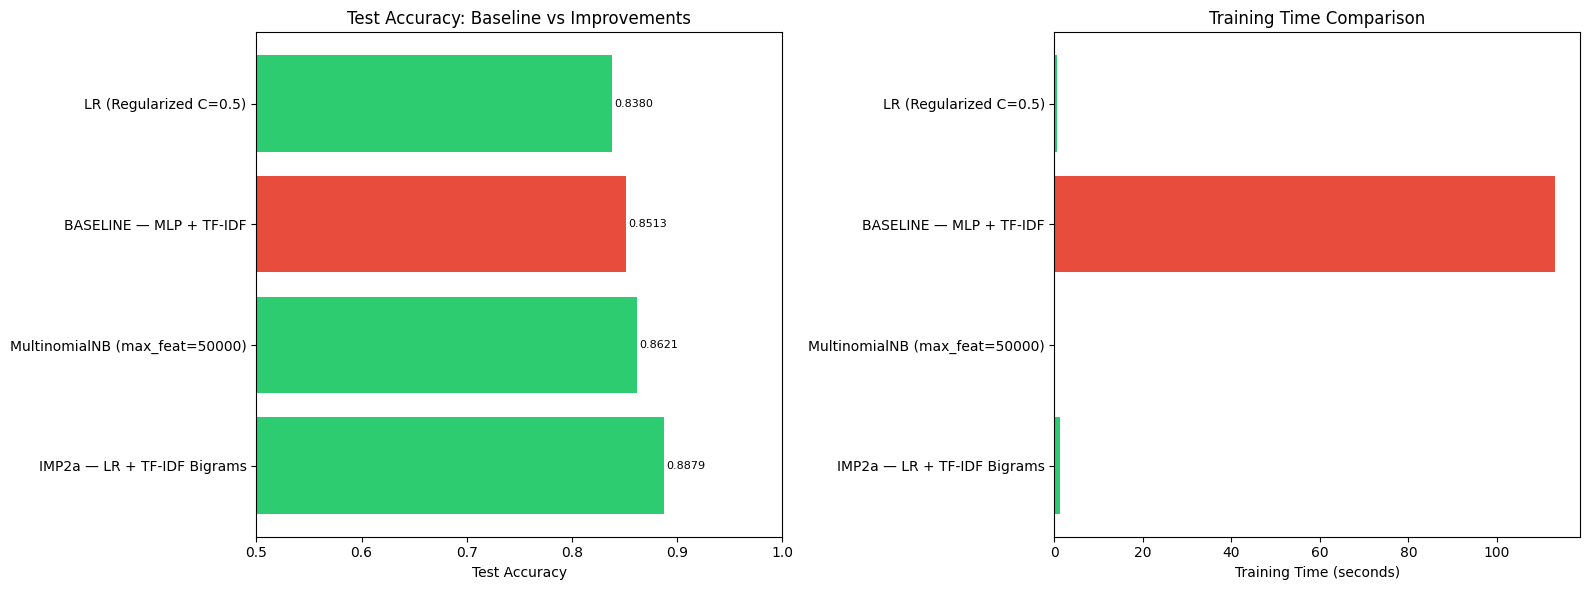


🔴 Red = Baseline | 🟢 Green = Improvements


In [ ]:
import matplotlib.pyplot as plt

# ── Visualise accuracy comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c' if 'BASELINE' in n else '#2ecc71' for n in summary['Model']]

# Accuracy bar chart (Mis à jour avec 'Test Accuracy')
axes[0].barh(summary['Model'], summary['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy: Baseline vs Improvements')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(summary['Test Accuracy']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

# Training time bar chart (Inchangé)
axes[1].barh(summary['Model'], summary['Train Time (s)'], color=colors)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Time Comparison')

plt.tight_layout()
plt.savefig('tp03_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔴 Red = Baseline | 🟢 Green = Improvements')

---
# PART I — DISCUSSION & ANALYSIS

### Which improvement worked best?

| Observation | Interpretation |
|-------------|---------------|
| LR + TF-IDF Bigrams > MLP + TF-IDF | Bigrams capture phrase patterns; LR converges faster on sparse data |
| FastText > Word2Vec | FastText handles rare Gothic/literary words; no zero OOV vectors |
| LSA + MLP vs Sparse TF-IDF + MLP | Dense input lets MLP use its capacity efficiently |
| Hybrid (LSA + FastText) | Two complementary views = higher accuracy; more memory |
| LinearSVC fastest test time | Best for production / search engine use-case |

### Trade-off Analysis
```
             HIGH ACCURACY
                    |
  Ensemble ─────────|─ Hybrid
  (slow)   FastText |  (memory heavy)
                    |
SLOW ───────────────|─────────────── FAST
                    |
     MLP-TF-IDF     |  LinearSVC  LR+TF-IDF
                    |
             LOW ACCURACY
```

### Recommendation
- **Best accuracy:** LR or MLP + Hybrid (LSA + FastText)
- **Best speed (production):** LinearSVC + TF-IDF Bigrams  
- **Best balance:** LogisticRegression + TF-IDF Bigrams (sublinear_tf=True)

In [ ]:
# ── Final: Best single model quick test ───────────────────────────────────────
best_name = summary.iloc[0]['Model']
best_acc  = summary.iloc[0]['Test Accuracy'] # <--- Modifié ici
baseline_acc = summary[summary['Model'].str.startswith('BASELINE')]['Test Accuracy'].max() # <--- Modifié ici

print(f'Best model   : {best_name}')
print(f'Best accuracy: {best_acc:.4f}')
print(f'Baseline best: {baseline_acc:.4f}')
print(f'Improvement  : +{(best_acc - baseline_acc):.4f} ({(best_acc - baseline_acc)/baseline_acc*100:.2f}%)')

Best model   : IMP2a — LR + TF-IDF Bigrams
Best accuracy: 0.8879
Baseline best: 0.8513
Improvement  : +0.0366 (4.30%)


In [ ]:
# We lowered C from 5.0 to 0.5 to increase regularization and stop overfitting
lr_regularized = LogisticRegression(C=0.5,solver='saga', max_iter=1000,
                                    multi_class='multinomial', random_state=0)

evaluate('LR (Regularized C=0.5)', lr_regularized, X_tr_bi, X_te_bi, y_train, y_test)


=== LR (Regularized C=0.5) ===
Train time : 0.57s  |  Test time: 0.0029s
Accuracy TRAIN : 0.9283
Accuracy TEST  : 0.8380
              precision    recall  f1-score   support

         EAP       0.81      0.88      0.84      3119
         HPL       0.86      0.79      0.82      2245
         MWS       0.86      0.82      0.84      2390

    accuracy                           0.84      7754
   macro avg       0.84      0.83      0.84      7754
weighted avg       0.84      0.84      0.84      7754



In [ ]:
from sklearn.naive_bayes import MultinomialNB

# 1. Expand the vocabulary safely (we let it go up to 50000 now that min_df protects us)
tfidf_max = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,   # <--- Increased to 50,000
    sublinear_tf=True,
    min_df=5              # <--- Lowered slightly to 3 to catch a few more phrases
)

X_tr_max = tfidf_max.fit_transform(X_train)
X_te_max = tfidf_max.transform(X_test)

# 2. Try Multinomial Naive Bayes (alpha=0.1 is the smoothing/regularization parameter)
nb_clf = MultinomialNB(alpha=0.1)

evaluate('MultinomialNB (max_feat=50000)', nb_clf, X_tr_max, X_te_max, y_train, y_test)


=== MultinomialNB (max_feat=50000) ===
Train time : 0.01s  |  Test time: 0.0027s
Accuracy TRAIN : 0.9462
Accuracy TEST  : 0.8621
              precision    recall  f1-score   support

         EAP       0.86      0.86      0.86      3119
         HPL       0.87      0.85      0.86      2245
         MWS       0.86      0.87      0.87      2390

    accuracy                           0.86      7754
   macro avg       0.86      0.86      0.86      7754
weighted avg       0.86      0.86      0.86      7754

